In [57]:
# ==============================================================================
# 1: VARIABLE DEFINITIONS
# ==============================================================================
 
# SoVI 2014
sovi_vars_2014 = [
    'MEDAGE', 'PERCAP', 'PPUNIT', 'QAGEDEP', 'QASIAN', 'QBLACK', 'QCVLUN', 'QED12LES',
    'QESL', 'QEXTRCT', 'QFEMALE', 'QFEMLBR', 'QFHH', 'QHISP', 'QHSEBRDN', 'QMOHO', 'QNATAM',
    'QNOAUTO', 'QUNINSUR', 'QPOVTY', 'QRENTER', 'QRICH200K', 'QSERV', 'QUNOCCHU', 'QSSBEN',
    'QFAM', 'MDHSEVAL', 'MDGRENT'
]
# SoVI 2019 - Removes MDHSEVAL, MDGRENT; replaces QFAM with QSNGPKIDS, adds QDISABL
sovi_vars_2019 = [
    'MEDAGE', 'PERCAP', 'PPUNIT', 'QAGEDEP', 'QASIAN', 'QBLACK', 'QCVLUN', 'QED12LES',
    'QESL', 'QEXTRCT', 'QFEMALE', 'QFEMLBR', 'QFHH', 'QHISP', 'QHSEBRDN', 'QMOHO', 'QNATAM',
    'QNOAUTO', 'QUNINSUR', 'QPOVTY', 'QRENTER', 'QRICH200K', 'QSERV', 'QUNOCCHU', 'QSSBEN',
    'QDISABLE', 'QSNGPKIDS'
]
# 2014 and 2019 combined - QFAM and QSNGPKIDS are inverses of each other, so choose either
sovi_vars_com = [
    'MEDAGE', 'PERCAP', 'PPUNIT', 'QAGEDEP', 'QASIAN', 'QBLACK', 'QCVLUN', 'QED12LES',
    'QESL', 'QEXTRCT', 'QFEMALE', 'QFEMLBR', 'QFHH', 'QHISP', 'QHSEBRDN', 'QMOHO', 'QNATAM',
    'QNOAUTO', 'QUNINSUR', 'QPOVTY', 'QRENTER', 'QRICH200K', 'QSERV', 'QUNOCCHU', 'QSSBEN',
    'QDISABLE', 'QSNGPKIDS', 'MDHSEVAL', 'MDGRENT'
]
 
# CHOOSE WHICH ONE:
sovi_vars_base = sovi_vars_2019

In [58]:
# ==============================================================================
# 2: DATA PREP AND CLEANING
# ==============================================================================
 
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import numpy as np
 
# STANDARD SOVI PROCEDURE FOR ANY STATE'S CENSUS TRACTS
 
# 2.1. Load and coerce
df_initial = pd.read_csv('../data/SoVI-vars-nationwide_2019.csv')
for col in sovi_vars_base:
    df_initial[col] = pd.to_numeric(df_initial[col], errors='coerce')
df_initial[sovi_vars_base] = df_initial[sovi_vars_base].mask(df_initial[sovi_vars_base] < 0, np.nan)
 
# 2.2. Choose state (comment out to use all CONUS tracts)
exclude_states = ['Alaska', 'Hawaii']
df_initial = df_initial[~df_initial['State Name'].isin(exclude_states)]
state = 'Tennessee'
df_initial = df_initial[df_initial['State Name'] == state]
 
# 2.3. Filter low-population tracts
pop_threshold, hhold_threshold = 50, 50
pop_mask = (df_initial['TOTALPOP'] > pop_threshold) & (df_initial['TOTALHHOLD'] > hhold_threshold)
num_dropped = len(df_initial) - pop_mask.sum()
df_initial = df_initial[pop_mask]
print(f"Dropped {num_dropped} tracts with low population/households.")
 
# 2.4. FIX: Impute FIRST on raw data, THEN scale.
#      V2 scaled before imputing, which meant NaNs influenced the mean/std fit
#      and KNN neighbors were selected in an already-distorted space.
 
# Step A: KNN imputation in raw variable units
num_missing = df_initial[sovi_vars_base].isnull().sum().sum()
imputer = KNNImputer(n_neighbors=5)
df_imputed_raw = pd.DataFrame(
    imputer.fit_transform(df_initial[sovi_vars_base]),
    columns=sovi_vars_base,
    index=df_initial.index
)
print(f"Total values imputed: {num_missing}")
 
# Step B: Z-score scaling on fully-imputed data
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_imputed_raw),
    columns=sovi_vars_base,
    index=df_initial.index
)
 

Dropped 26 tracts with low population/households.
Total values imputed: 0


Kaiser criterion: 5 components retained


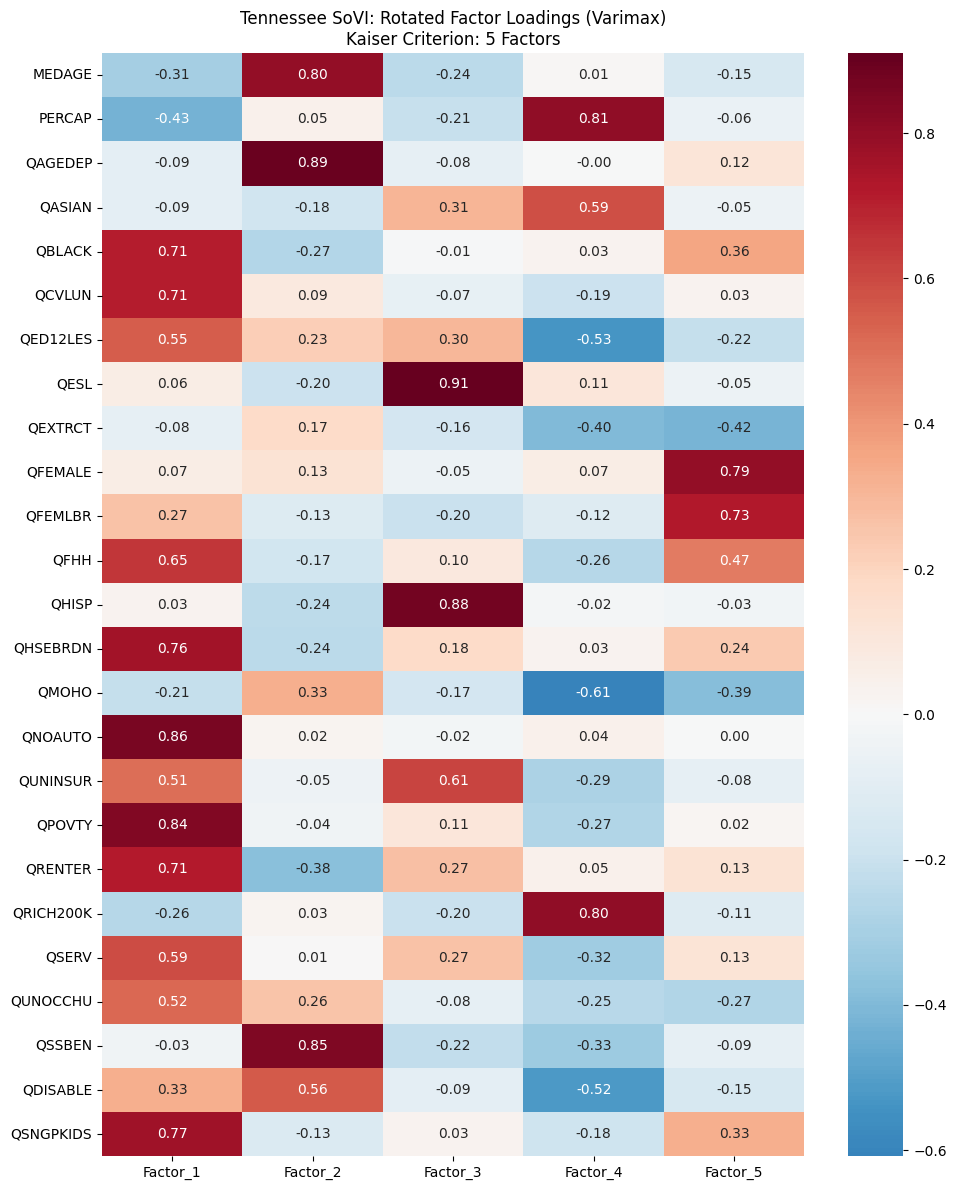

In [59]:
# ==============================================================================
# CELL 3: PCA + VARIMAX
# ==============================================================================
 
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from factor_analyzer.rotator import Rotator
 
# FIX: vars_to_drop is applied locally here so this cell is self-contained.
#      In V2, dropping vars mutated the global sovi_vars list, requiring a
#      re-run of the data prep cell to reset it. Now we derive a clean working
#      list each time this cell runs without touching sovi_vars_base.
vars_to_drop = ['QNATAM', 'PPUNIT']
sovi_vars = [v for v in sovi_vars_base if v not in vars_to_drop]
 
# Work from the scaled data
df_pca_input = df_scaled[sovi_vars]
 
# 3.1. Initial PCA to determine number of components (Kaiser criterion: eigenvalue > 1)
pca_init = PCA()
pca_init.fit(df_pca_input)
eigenvalues = pca_init.explained_variance_
n_comp = len(eigenvalues[eigenvalues > 1])
print(f"Kaiser criterion: {n_comp} components retained")
 
# 3.2. Extract unrotated loadings
pca_final = PCA(n_components=n_comp)
pca_final.fit(df_pca_input)
unrotated_loadings = pca_final.components_.T * np.sqrt(pca_final.explained_variance_)
 
# 3.3. Varimax rotation
rotator = Rotator(method='varimax')
rotated_loadings = rotator.fit_transform(unrotated_loadings)
 
loadings_rotated = pd.DataFrame(
    rotated_loadings,
    columns=[f'Factor_{i+1}' for i in range(n_comp)],
    index=sovi_vars
)
 
# 3.4. Heatmap
plt.figure(figsize=(10, 12))
sns.heatmap(loadings_rotated, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title(f'{state} SoVI: Rotated Factor Loadings (Varimax)\nKaiser Criterion: {n_comp} Factors')
plt.tight_layout()
plt.show()

In [60]:
# ==============================================================================
# 4: CALCULATE SoVI SCORES
# ==============================================================================
 
from scipy.stats.mstats import winsorize
 
# 4.1. Factor score coefficients
#      FIX (V2): V2 used pinv(loadings) which bypasses the correlation structure.
#      Correct method: R⁻¹ × L where R is the correlation matrix of the scaled data.
#      Using np.linalg.inv explicitly; falls back to pinv if R is near-singular.
R = df_pca_input.corr().values
try:
    R_inv = np.linalg.inv(R)
except np.linalg.LinAlgError:
    print("Warning: correlation matrix is singular; falling back to pseudoinverse.")
    R_inv = np.linalg.pinv(R)
weights = R_inv.dot(rotated_loadings)
 
# 4.2. Factor scores for every tract
factor_scores = pd.DataFrame(
    df_pca_input.values.dot(weights),
    columns=[f'Factor_{i+1}' for i in range(n_comp)],
    index=df_initial.index
)
 
# 4.3. FIX: Auto-detect which factors need inversion.
#      A factor should be inverted if its dominant loading comes from a
#      positively-valenced variable (i.e., higher = less vulnerable).
#      V2 hardcoded factor numbers, which breaks if factor order shifts.
POSITIVE_ANCHORS = {'PERCAP', 'QRICH200K'}
 
factors_to_invert = []
for col in factor_scores.columns:
    factor_loadings = loadings_rotated[col].abs()
    dominant_var = factor_loadings.idxmax()
    dominant_loading_sign = loadings_rotated.loc[dominant_var, col]
    if dominant_var in POSITIVE_ANCHORS and dominant_loading_sign > 0:
        factors_to_invert.append(col)
    # Also invert if a positive anchor has the largest absolute loading
    # AND its loading is negative (factor already points toward vulnerability —
    # but dominant var is negative anchor — leave it alone)
 
print(f"Auto-detected factors to invert: {factors_to_invert}")
print("(Review against heatmap — override manually below if needed)\n")
 
# Optional manual override — uncomment and set if auto-detection is wrong:
# factors_to_invert = ['Factor_4']
 
# 4.4. Apply inversions
#      FIX (V2): The if-block was outside the for-loop due to wrong indentation,
#      so only the last factor in the list was ever actually inverted.
factor_scores_adjusted = factor_scores.copy()
for col in factors_to_invert:
    if col in factor_scores_adjusted.columns:
        factor_scores_adjusted[col] = factor_scores_adjusted[col] * -1
        print(f"Inverted: {col}")
 
# 4.5. FIX: Winsorize each factor individually BEFORE summing.
#      V2 winsorized the composite score, which meant the factor columns in df_final
#      were inconsistent with the reported SoVI_Score at the tails.
for col in factor_scores_adjusted.columns:
    factor_scores_adjusted[col] = winsorize(
        factor_scores_adjusted[col], limits=[0.01, 0.01]
    )
 
# 4.6. Final SoVI score = sum of (winsorized, inverted) factors
df_initial['SoVI_Score'] = factor_scores_adjusted.sum(axis=1)
 
# Merge factor scores into main dataframe
df_final = pd.concat([df_initial, factor_scores_adjusted], axis=1)
print("\nFinal SoVI calculation complete!\n")
 
# Variance summary
var_exp = pca_init.explained_variance_ratio_
cum_var_exp = np.cumsum(var_exp)
print(f"{'Factor':<10} | {'Expl. Var (%)':<15} | {'Cumul. Var (%)'}")
print("-" * 45)
for i in range(n_comp):
    print(f"Factor {i+1:<3} | {var_exp[i]*100:<15.2f}% | {cum_var_exp[i]*100:.2f}%")
 
print("")
print(df_final.head())
 
df_final.to_csv(f'../results/SoVI-{state}_2019.csv')

Auto-detected factors to invert: ['Factor_4']
(Review against heatmap — override manually below if needed)

Inverted: Factor_4

Final SoVI calculation complete!

Factor     | Expl. Var (%)   | Cumul. Var (%)
---------------------------------------------
Factor 1   | 31.86          % | 31.86%
Factor 2   | 19.10          % | 50.97%
Factor 3   | 10.44          % | 61.40%
Factor 4   | 5.10           % | 66.50%
Factor 5   | 4.83           % | 71.33%

             GEOID State Name County Name  Year  TOTALPOP  TOTALHHOLD  \
60132  47001020100  Tennessee   Anderson   2019      3196        1510   
60133  47001020201  Tennessee   Anderson   2019      4080        1712   
60134  47001020202  Tennessee   Anderson   2019      3973        1731   
60135  47001020300  Tennessee   Anderson   2019      3851        1486   
60136  47001020400  Tennessee   Anderson   2019      4275        1877   

       QAGEDEP  QFEMALE  MEDAGE  QBLACK  ...  QDISABLE  QUNOCCHU  MDGRENT  \
60132   0.2369   0.5332    34.6  0

In [61]:
# ==============================================================================
# CELL 4B: VARIANCE-WEIGHTED SoVI SCORE
# Standard SoVI sums factors equally. This version weights each factor by its
# share of total explained variance before summing, so factors that capture
# more of the data structure contribute proportionally more to the final score.
# ==============================================================================

# 4B.1. Get explained variance ratios for the retained components only
#       (pca_init has all components; slice to n_comp)
retained_var = pca_init.explained_variance_ratio_[:n_comp]
weights_ev = retained_var / retained_var.sum()  # normalize to sum to 1

print("Explained variance weights per factor:")
for i, (w, v) in enumerate(zip(weights_ev, retained_var)):
    print(f"  Factor_{i+1}: {v*100:.2f}% explained  →  weight {w:.4f}")

# 4B.2. Apply weights to the already-inverted, already-winsorized factor scores
#       (factor_scores_adjusted already has inversions and winsorization from Cell 4)
factor_scores_weighted = factor_scores_adjusted * weights_ev

# 4B.3. Weighted SoVI score
df_final['SoVI_Score_Weighted'] = factor_scores_weighted.sum(axis=1)

# 4B.4. Quick comparison of the two scores
print("\nScore comparison (unweighted vs weighted):")
print(df_final[['SoVI_Score', 'SoVI_Score_Weighted']].describe().round(4))

# Correlation between the two — high correlation means weighting doesn't change
# the relative ranking much; low correlation means it matters significantly
corr = df_final['SoVI_Score'].corr(df_final['SoVI_Score_Weighted'])
print(f"\nPearson correlation between scores: {corr:.4f}")

# 4B.5. Export — both scores in the same file
df_final.to_csv(f'../results/SoVI-2019_{state}.csv', index=False)
print("\nExported with both SoVI_Score and SoVI_Score_Weighted.")

Explained variance weights per factor:
  Factor_1: 31.86% explained  →  weight 0.4467
  Factor_2: 19.10% explained  →  weight 0.2678
  Factor_3: 10.44% explained  →  weight 0.1463
  Factor_4: 5.10% explained  →  weight 0.0715
  Factor_5: 4.83% explained  →  weight 0.0677

Score comparison (unweighted vs weighted):
       SoVI_Score  SoVI_Score_Weighted
count   1471.0000            1471.0000
mean      -0.0109              -0.0045
std        2.1425               0.5333
min       -7.6253              -1.2445
25%       -1.2544              -0.3763
50%        0.1121              -0.0789
75%        1.3542               0.2719
max        6.4587               1.8852

Pearson correlation between scores: 0.8147

Exported with both SoVI_Score and SoVI_Score_Weighted.


In [62]:
# ==============================================================================
# 5: SPATIAL JOIN + EXPORT
# ==============================================================================
 
import geopandas as gpd
 
shapefile_path = '/Users/maxbdixon/Documents/QGIS/cb_2019_us_tract_500k/cb_2019_us_tract_500k.shp'
gdf = gpd.read_file(shapefile_path)
gdf['GEOID'] = gdf['GEOID'].astype(str).str.zfill(11)
gdf = gdf.set_index("GEOID")
 
results_indexed = df_final.copy()
geoids = df_initial['GEOID'].astype(str).str.zfill(11)
if 'GEOID' in results_indexed.columns:
    results_indexed = results_indexed.drop(columns=['GEOID'])
results_indexed.index = geoids
 
gdf_final = gdf[['geometry']].join(results_indexed, how='inner')
 
unique_states = gdf_final.index.str[:2].unique()
print(f"Success! Joined data contains {len(gdf_final)} tracts across State FIPS: {list(unique_states)}")
 
if not gdf_final.empty:
    output_file = f'../results/SoVI_2019_{state}.gpkg'
    gdf_final.reset_index().to_file(output_file, driver="GPKG")
    print(f"Saved to: {output_file}")
else:
    print("Join failed. No matching GEOIDs found.")

Success! Joined data contains 1471 tracts across State FIPS: ['47']
Saved to: ../results/SoVI_2019_Tennessee.gpkg


In [63]:
# ==============================================================================
# 6: K-MEANS QUALITY CHECKS
# ==============================================================================
 
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.spatial.distance import cdist, pdist
 
comp_range = range(6, 7)
k_range = range(2, 11)
results = []
 
scaler_km = StandardScaler()
X_full_scaled = scaler_km.fit_transform(factor_scores)
 
print(f"{'Comp':<5} | {'K':<3} | {'Silh (↑)':<8} | {'D-B (↓)':<8} | {'Within (↓)':<10} | {'Inter (↑)'}")
print("-" * 65)
 
for n_comp_km in comp_range:
    X_subset = X_full_scaled[:, :n_comp_km]
    tss_subset = np.sum((X_subset - np.mean(X_subset, axis=0))**2)
 
    for k in k_range:
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        labels = km.fit_predict(X_subset)
        centroids = km.cluster_centers_
 
        pt_to_centroid_dist = np.min(cdist(X_subset, centroids, 'euclidean'), axis=1)
        avg_within_dist = np.mean(pt_to_centroid_dist)
 
        avg_inter_dist = np.mean(pdist(centroids, 'euclidean')) if k > 1 else 0
 
        sil = silhouette_score(X_subset, labels)
        db = davies_bouldin_score(X_subset, labels)
        var_exp_km = (1 - (km.inertia_ / tss_subset)) * 100
 
        results.append({
            'Components': n_comp_km, 'K': k, 'Silhouette': sil,
            'Davies_Bouldin': db, 'Var_Exp_Pct': var_exp_km,
            'Avg_Within_Dist': avg_within_dist, 'Avg_Inter_Dist': avg_inter_dist
        })
        print(f"{n_comp_km:<5} | {k:<3} | {sil:<8.3f} | {db:<8.3f} | {avg_within_dist:<10.3f} | {avg_inter_dist:.3f}")
 
summary_df = pd.DataFrame(results)

Comp  | K   | Silh (↑) | D-B (↓)  | Within (↓) | Inter (↑)
-----------------------------------------------------------------
6     | 2   | 0.248    | 2.115    | 1.823      | 1.878
6     | 3   | 0.203    | 1.747    | 1.653      | 2.246
6     | 4   | 0.237    | 1.437    | 1.548      | 2.942
6     | 5   | 0.228    | 1.303    | 1.445      | 3.135
6     | 6   | 0.212    | 1.249    | 1.364      | 3.070
6     | 7   | 0.215    | 1.230    | 1.316      | 3.150
6     | 8   | 0.221    | 1.195    | 1.278      | 3.245
6     | 9   | 0.223    | 1.188    | 1.253      | 3.530
6     | 10  | 0.189    | 1.253    | 1.210      | 3.315


In [64]:
# ==============================================================================
# CELL 6B: UMAP QUALITY CHECKS ON RAW SCALED VARIABLES (PRE-PCA)
# Bypasses PCA entirely — UMAP reduces directly from the full variable space.
# Compare these metrics to Cell 7 to see if PCA is helping or hurting cluster separation.
# ==============================================================================

import umap

scaler_raw = StandardScaler()
X_scaled_raw = scaler_raw.fit_transform(df_scaled[sovi_vars])

reducer_raw = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_embedded_raw = reducer_raw.fit_transform(X_scaled_raw)

global_mean_raw = np.mean(X_embedded_raw, axis=0)
tss_raw = np.sum((X_embedded_raw - global_mean_raw)**2)

print(f"{'K':<3} | {'Silh (↑)':<7} | {'DB (↓)':<7} | {'Expl %':<8} | {'Within (↓)':<10} | {'Inter (↑)'}")
print("-" * 65)

results_raw = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    labels = km.fit_predict(X_embedded_raw)
    centroids = km.cluster_centers_

    sil = silhouette_score(X_embedded_raw, labels)
    db_index = davies_bouldin_score(X_embedded_raw, labels)
    explained_var = (1 - (km.inertia_ / tss_raw)) * 100
    avg_within = np.mean(np.min(cdist(X_embedded_raw, centroids, 'euclidean'), axis=1))
    avg_inter = np.mean(pdist(centroids, 'euclidean')) if k > 1 else 0

    results_raw.append({
        'K': k, 'Silhouette': sil, 'DB_Index': db_index,
        'Expl_Var': explained_var, 'Avg_Inter': avg_inter
    })
    print(f"{k:<3} | {sil:<7.3f} | {db_index:<7.3f} | {explained_var:<7.1f}% | {avg_within:<10.3f} | {avg_inter:.3f}")

summary_raw_df = pd.DataFrame(results_raw)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


K   | Silh (↑) | DB (↓)  | Expl %   | Within (↓) | Inter (↑)
-----------------------------------------------------------------
2   | 0.461   | 0.857   | 51.2   % | 1.952      | 4.477
3   | 0.499   | 0.694   | 74.0   % | 1.453      | 4.564
4   | 0.430   | 0.827   | 79.8   % | 1.270      | 4.310
5   | 0.407   | 0.871   | 84.6   % | 1.129      | 4.452
6   | 0.418   | 0.811   | 87.4   % | 1.028      | 4.160
7   | 0.412   | 0.818   | 89.2   % | 0.954      | 4.127
8   | 0.403   | 0.853   | 90.6   % | 0.889      | 4.094
9   | 0.390   | 0.886   | 91.8   % | 0.827      | 4.247
10  | 0.396   | 0.830   | 92.8   % | 0.767      | 4.276


In [65]:
# ==============================================================================
# 7: UMAP QUALITY CHECKS
# ==============================================================================
 
import umap
 
# NOTE ON UMAP NON-DETERMINISM:
#   random_state=42 fixes the random seed but UMAP's topology can still shift
#   meaningfully when input data changes (e.g. different state, dropped vars).
#   Treat UMAP cluster results as exploratory — don't compare cluster IDs
#   across separate runs without re-validating the embedding.
 
scaler_umap = StandardScaler()
X_scaled_umap = scaler_umap.fit_transform(factor_scores)
 
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_embedded = reducer.fit_transform(X_scaled_umap)
 
global_mean = np.mean(X_embedded, axis=0)
tss_umap = np.sum((X_embedded - global_mean)**2)
 
results_umap = []
k_range_umap = range(2, 11)
 
print(f"{'K':<3} | {'Silh (↑)':<7} | {'DB (↓)':<7} | {'Expl %':<8} | {'Within (↓)':<10} | {'Inter (↑)'}")
print("-" * 65)
 
for k in k_range_umap:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    labels = km.fit_predict(X_embedded)
    centroids = km.cluster_centers_
 
    sil = silhouette_score(X_embedded, labels)
    db_index = davies_bouldin_score(X_embedded, labels)
    sse = km.inertia_
    explained_var = (1 - (sse / tss_umap)) * 100
    avg_within = np.mean(np.min(cdist(X_embedded, centroids, 'euclidean'), axis=1))
    avg_inter = np.mean(pdist(centroids, 'euclidean')) if k > 1 else 0
 
    results_umap.append({
        'K': k, 'Silhouette': sil, 'DB_Index': db_index,
        'Expl_Var': explained_var, 'Avg_Inter': avg_inter
    })
    print(f"{k:<3} | {sil:<7.3f} | {db_index:<7.3f} | {explained_var:<7.1f}% | {avg_within:<10.3f} | {avg_inter:.3f}")
 
summary_umap_df = pd.DataFrame(results_umap)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


K   | Silh (↑) | DB (↓)  | Expl %   | Within (↓) | Inter (↑)
-----------------------------------------------------------------
2   | 0.459   | 0.840   | 53.4   % | 2.272      | 5.359
3   | 0.478   | 0.746   | 72.0   % | 1.793      | 5.229
4   | 0.418   | 0.827   | 78.8   % | 1.547      | 5.143
5   | 0.392   | 0.923   | 82.9   % | 1.396      | 5.111
6   | 0.414   | 0.873   | 86.4   % | 1.246      | 4.902
7   | 0.425   | 0.767   | 88.7   % | 1.142      | 4.922
8   | 0.420   | 0.780   | 90.6   % | 1.038      | 4.944
9   | 0.419   | 0.743   | 91.8   % | 0.971      | 5.003
10  | 0.418   | 0.748   | 92.8   % | 0.909      | 4.952


In [68]:
# ==============================================================================
# CELL 8: UMAP CLUSTERING + EXPORT (PCA FACTORS + RAW VARIABLES)
# ==============================================================================

N_COMPONENTS = n_comp
K_CLUSTERS = 5
output_path = f"../results/K-SoVI_UMAP_2019_{state}.gpkg"

gdf_clust = gpd.read_file(f'../results/SoVI_2019_{state}.gpkg')

# Attach unscaled QPOVTY from df_initial for cluster sorting
qpovty_raw = df_initial['QPOVTY'].reset_index(drop=True)

for version, X_input in [
    ('PCA', factor_scores_adjusted.values),
    ('RAW', df_scaled[sovi_vars].values)
]:
    print(f"\n--- UMAP CLUSTERING: {version} ---")

    scaler_clust = StandardScaler()
    X_scaled_clust = scaler_clust.fit_transform(X_input)

    reducer_clust = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    X_embedded_clust = reducer_clust.fit_transform(X_scaled_clust)

    km_final = KMeans(n_clusters=K_CLUSTERS, init='k-means++', n_init=100, random_state=42)
    raw_labels = km_final.fit_predict(X_embedded_clust)

    # Sort by unscaled QPOVTY ascending — cluster 1 = lowest poverty, N = highest
    temp = pd.DataFrame({'raw_cluster': raw_labels, 'QPOVTY': qpovty_raw})
    poverty_rank = temp.groupby('raw_cluster')['QPOVTY'].mean().sort_values(ascending=True).index
    cluster_map = {old: i + 1 for i, old in enumerate(poverty_rank)}
    gdf_clust[f'SoVI_Cluster_{version}'] = pd.Series(raw_labels).map(cluster_map).values

    # Summary table from unscaled df_initial
    available_vars = [v for v in sovi_vars if v in df_initial.columns]
    if available_vars:
        print("\n--- MEAN CENSUS VARIABLES BY CLUSTER (UNSCALED) ---")
        summary_df = df_initial[available_vars].copy().reset_index(drop=True)
        summary_df['cluster'] = gdf_clust[f'SoVI_Cluster_{version}'].values
        summary_table = summary_df.groupby('cluster')[available_vars].mean().T
        summary_table.columns = [f'Cluster {int(c)}' for c in summary_table.columns]
        try:
            display(summary_table.round(3))
        except NameError:
            print(summary_table.round(3))

    print("\n--- CLUSTER SIZES ---")
    print(gdf_clust[f'SoVI_Cluster_{version}'].value_counts().sort_index())

gdf_clust.to_file(output_path, driver='GPKG')
print(f"\nSaved: {output_path}")
print(f"Columns: SoVI_Cluster_PCA, SoVI_Cluster_RAW")


--- UMAP CLUSTERING: PCA ---


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



--- MEAN CENSUS VARIABLES BY CLUSTER (UNSCALED) ---


,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5
MEDAGE,40.300,43.574,43.956,32.864,35.096
PERCAP,47633.688,28491.580,23770.949,26039.593,19675.885
QAGEDEP,0.219,0.257,0.245,0.168,0.211
QASIAN,0.035,0.008,0.004,0.018,0.017
QBLACK,0.077,0.081,0.037,0.323,0.520
QCVLUN,0.029,0.051,0.063,0.059,0.101
QED12LES,0.049,0.126,0.181,0.112,0.208
QESL,0.022,0.012,0.009,0.039,0.081
QEXTRCT,0.004,0.010,0.035,0.004,0.004
QFEMALE,0.511,0.524,0.488,0.517,0.523



--- CLUSTER SIZES ---
SoVI_Cluster_PCA
1    266
2    400
3    313
4    248
5    244
Name: count, dtype: int64

--- UMAP CLUSTERING: RAW ---


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



--- MEAN CENSUS VARIABLES BY CLUSTER (UNSCALED) ---


,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5
MEDAGE,39.465,43.740,44.361,33.744,34.815
PERCAP,46740.669,28688.517,23821.084,24861.360,18368.094
QAGEDEP,0.210,0.258,0.249,0.184,0.208
QASIAN,0.036,0.007,0.004,0.023,0.006
QBLACK,0.088,0.064,0.035,0.220,0.764
QCVLUN,0.028,0.051,0.062,0.057,0.120
QED12LES,0.047,0.127,0.179,0.146,0.190
QESL,0.023,0.011,0.010,0.082,0.025
QEXTRCT,0.003,0.010,0.035,0.005,0.003
QFEMALE,0.515,0.518,0.493,0.508,0.539



--- CLUSTER SIZES ---
SoVI_Cluster_RAW
1    293
2    358
3    332
4    297
5    191
Name: count, dtype: int64

Saved: ../results/K-SoVI_UMAP_2019_Tennessee.gpkg
Columns: SoVI_Cluster_PCA, SoVI_Cluster_RAW


In [41]:
import geopandas as gpd
import os

# ==============================================================================
# CELL 9: BIN SoVI SCORES INTO UMAP-MATCHED BINS
# Uses the same number of bins as UMAP clusters (K_CLUSTERS from Cell 8)
# so the two classification approaches are directly comparable.
# Bins are equal-width by default; quantile option also available.
# ==============================================================================

# 9.1. Pull K from Cell 8 (already in memory)
n_bins = K_CLUSTERS
print(f"Binning into {n_bins} bins (matching UMAP cluster count)\n")

# 9.2. Equal-width bins for both scores
#      Labels: 1 = lowest vulnerability, n_bins = highest
bin_labels = list(range(1, n_bins + 1))

df_final['SoVI_Bin'] = pd.qcut(
    df_final['SoVI_Score'],
    q=n_bins,
    labels=bin_labels,
    duplicates='drop'
).astype(int)
df_final['SoVI_Bin_Weighted'] = pd.qcut(
    df_final['SoVI_Score_Weighted'],
    q=n_bins,
    labels=bin_labels,
    duplicates='drop'
).astype(int)

# 9.3. Print bin distributions
print("--- UNWEIGHTED BIN DISTRIBUTION ---")
print(df_final['SoVI_Bin'].value_counts().sort_index().to_string())
print("\n--- WEIGHTED BIN DISTRIBUTION ---")
print(df_final['SoVI_Bin_Weighted'].value_counts().sort_index().to_string())

# 9.4. Agreement between the two binnings
agreement = (df_final['SoVI_Bin'] == df_final['SoVI_Bin_Weighted']).mean()
print(f"\nBin agreement (same bin in both): {agreement*100:.1f}% of tracts")

# 9.5. Cross-tab: where do they disagree?
print("\n--- CROSS-TAB (unweighted rows x weighted cols) ---")
ct = pd.crosstab(
    df_final['SoVI_Bin'],
    df_final['SoVI_Bin_Weighted'],
    rownames=['Unweighted'],
    colnames=['Weighted']
)
print(ct)

# 9.6. Export updated file with bin columns
df_final.to_csv('../results/SoVI-TN_2019_v3.csv', index=False)

# Also update the GeoPackage if it exists
gpkg_path = f'../results/K-SoVI_UMAP_2019_{state}.gpkg'
if os.path.exists(gpkg_path):
    gdf_out = gpd.read_file(gpkg_path)
    gdf_out = gdf_out.merge(
    df_final[['GEOID', 'SoVI_Score_Weighted', 'SoVI_Bin', 'SoVI_Bin_Weighted']].assign(GEOID=df_final['GEOID'].astype(str).str.zfill(11)),
    on='GEOID',
    how='left'
)

    gdf_out = gdf_out.to_crs(epsg=32616)  # UTM Zone 16N — appropriate for Tennessee
    gdf_out.to_file(gpkg_path, driver='GPKG')
    print(f"\nGeoPackage updated: {gpkg_path}")

Binning into 6 bins (matching UMAP cluster count)

--- UNWEIGHTED BIN DISTRIBUTION ---
SoVI_Bin
1    246
2    245
3    245
4    245
5    245
6    245

--- WEIGHTED BIN DISTRIBUTION ---
SoVI_Bin_Weighted
1    246
2    245
3    245
4    245
5    245
6    245

Bin agreement (same bin in both): 51.7% of tracts

--- CROSS-TAB (unweighted rows x weighted cols) ---
Weighted      1    2    3    4    5    6
Unweighted                              
1           163   57   15    6    3    2
2            75  103   39   19    6    3
3             7   65  109   44   15    5
4             1   16   59  100   59   10
5             0    4   21   67  107   46
6             0    0    2    9   55  179

GeoPackage updated: ../results/K-SoVI_UMAP_2019_Tennessee.gpkg
